# Rebuttal trivia-qa without context

* TLDR: performance only drops a bit, in the logs we now see real hallucinations

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'goatml'

In [2]:
# export to eval file
def get_vals(x):
    return x['mean'], x['mean']-x['bootstrap']['std_err'], x['mean']+x['bootstrap']['std_err']

def get_vals2(x):
    return x['means'], x['low'], x['high']


def get_perfs(metrics):
    data = []
    for method in metrics['performance']:
        mean, low, high = get_vals(metrics['performance'][method])
        data.append([method, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'means', 'low', 'high'])
    return df.set_index('method')

def plot_bar(df, color='C0', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    df.plot.bar(y='means', yerr=[df.means - df.low, df.high - df.means], color=color, ax=ax)

def get_uncertainty_df(metrics):
    data = []
    for method in metrics['uncertainty']:
        for metric in metrics['uncertainty'][method]:
            mean, low, high = get_vals(metrics['uncertainty'][method][metric])
            data.append([method, metric, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'metric', 'means', 'low', 'high'])
    
    df = df.set_index('method')

    def get_base_method(x):
        if 'p_false' in x:
            return 'p_false'
        elif 'p_ik' in x:
            return 'p_ik'
        elif 'regular_entropy' in x:
            return 'regular_entropy'
        elif 'cluster_assignment' in x:
            return x
        elif 'semantic_entropy' in x:
            return 'semantic_entropy'
        else:
            raise
    df['base_method'] = df.index.map(get_base_method)
    return df

def plot_bar_uncertainty(pdf, metric, remove='_UNANSWERABLE', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    tmp = pdf
    # filter out unanswerable
    if remove is not None:
        tmp = tmp[tmp.index.map(lambda x: remove not in x)]
    tmp = tmp.reset_index()
    tmp = tmp.set_index('metric').loc[metric]
    tmp = tmp.set_index('method')
    tmp = tmp.sort_values('base_method')

    b2c = {m:f'C{i}' for i, m in enumerate(tmp.base_method.unique())}
    basemethod2color = lambda x: b2c[x]

    plot_bar(tmp, color=tmp.base_method.map(basemethod2color), ax=ax)
    ax.grid(axis='y', zorder=-10, alpha=0.3)

In [3]:
def restore_file(wandb_id, filenames=['wandb-summary.json', 'config.yaml']):
    files_dir = 'notebooks/restored_files'    
    os.system(f'mkdir -p {files_dir}')

    run = api.run(f'goatml/semantic_uncertainty/{wandb_id}')
    # run = api.run(f'goatml/uncertainty/{wandb_id}')
    out = []

    for filename in filenames:
        
        path = f'{files_dir}/{filename}'
        os.system(f'rm -rf {path}')
        run.file(filename).download(root=files_dir, replace=True, exist_ok=False)
    
        if filename.endswith('.pkl'):
            with open(path, 'rb') as f:
                out.append(pickle.load(f))
        elif filename.endswith('.yaml'):
            with open(path, 'r') as f:
                out.append(yaml.safe_load(f))
        elif filename.endswith('.json'):
            with open(path, 'r') as f:
                out.append(json.load(f))
        else:
            raise

    return out

In [4]:
# The new runs are doing strict entailment _and_ condition on question,
runs = {
#     'sy2g4uyv': '70b-trivia-qa',
#     'ispvyuub': '70b-trivia-no-context',
#     # NOTE: 70-bSQUAD RUNS ONLY HAVE 5 GENERATIONS !!
#     '3dh1kja3': '70b-squad', # n2bhdjad
#     'jky7j51k': '70b-squad-AO', # answerable only 'ttd2db7b''
#     'zodwzypf': '70b-squad-AO-NC', # answerable only, no-context 'ttd2db7b''
# # 
#     '4qrza8sl': '7b-trivia-qa',
#     'gk0phirh': '7b-trivia-no-context',
#     '7nlpwfzq': '7b-squad', # n2bhdjad
#     'bd90qu2n': '7b-squad-AO', # answerable only 'ttd2db7b''
#     'cizk4p88': '7b-squad-AO-NC', # answerable only, no-context 'ttd2db7b''
# 
    'jjggmw43': '7b-squad', # AO/NC
    '0hyjzs16': '7b-trivia_qa',  # NC
    'z4r9jeiz': '7b-bioasq',
    'ooslwgb9': '70b-squad',
    'au7s3uxg': '70b-trivia_qa',
    'e5ptgcwr': '70b-bioasq',
    'zs85ypn3': '70b-record',
}

all_configs, all_results = {}, {}

for wandb_id in runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)


In [5]:
# python compute_uncertainty_measures.py --eval_wandb_runid=ooslwgb9 --entailment_model=gpt-4 -- > ///wandb.ai/goatml/semantic_uncertainty/runs/e0z3555u

Can we improve accuracy by instead voting the answer from the (high-temperature) clusters?

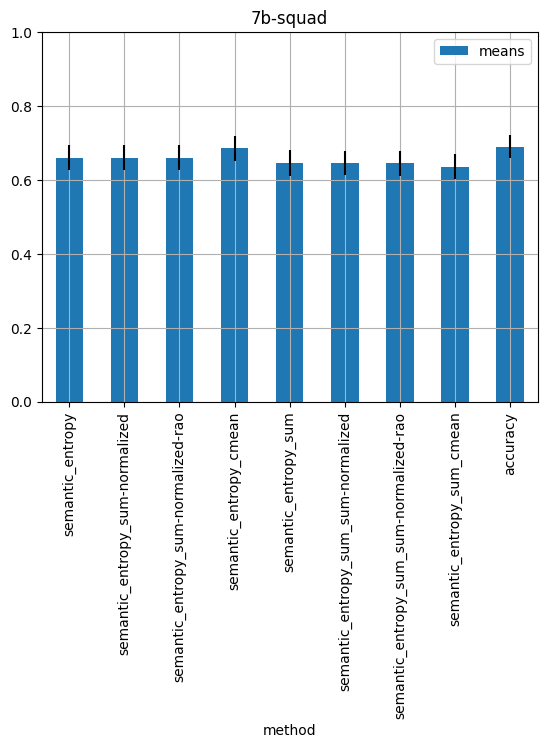

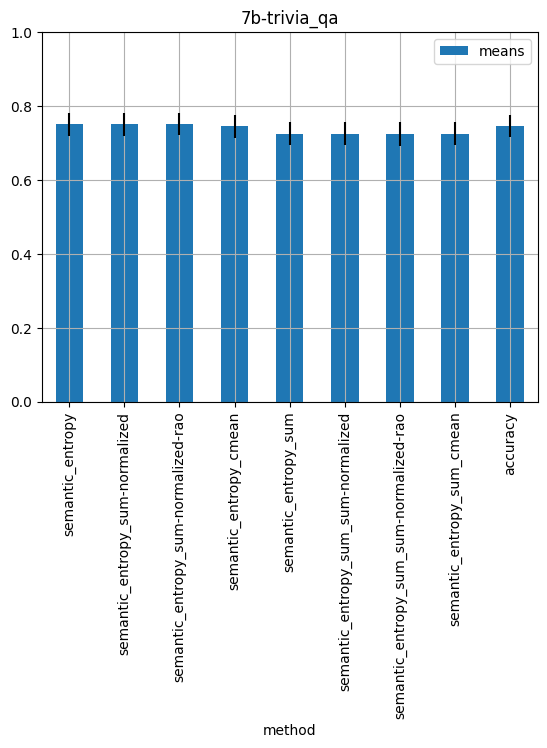

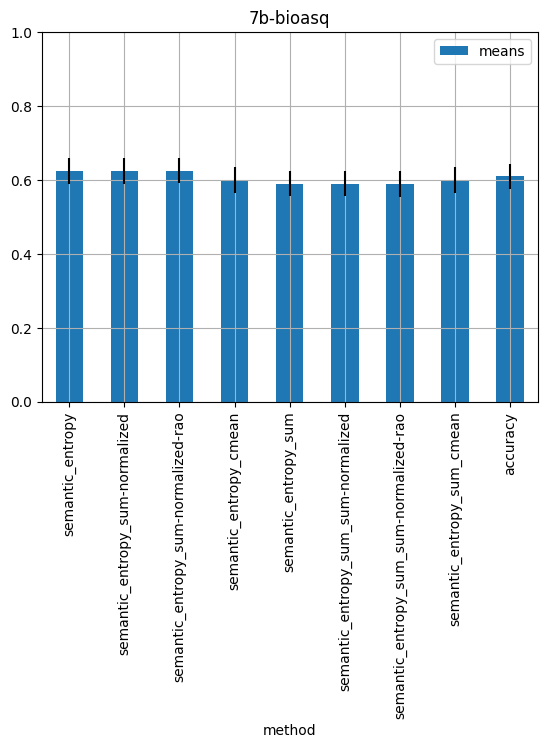

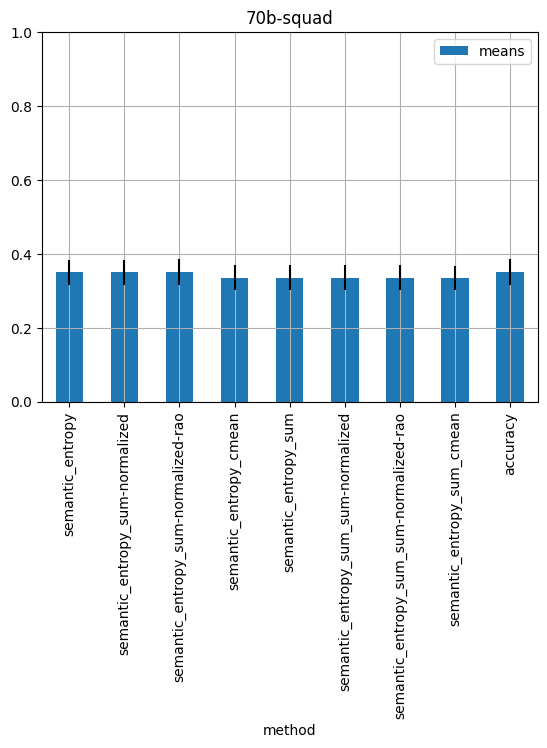

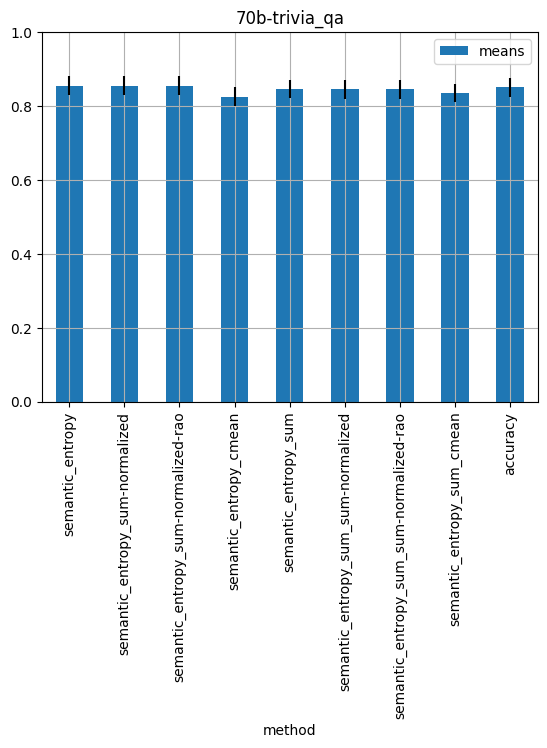

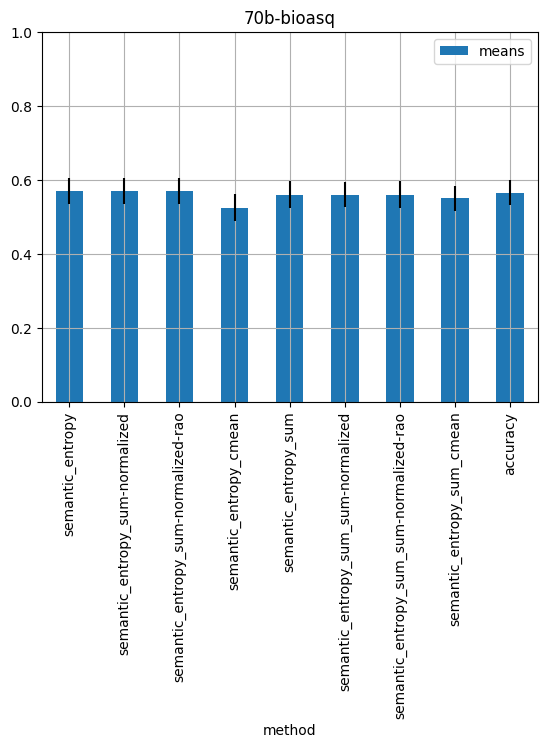

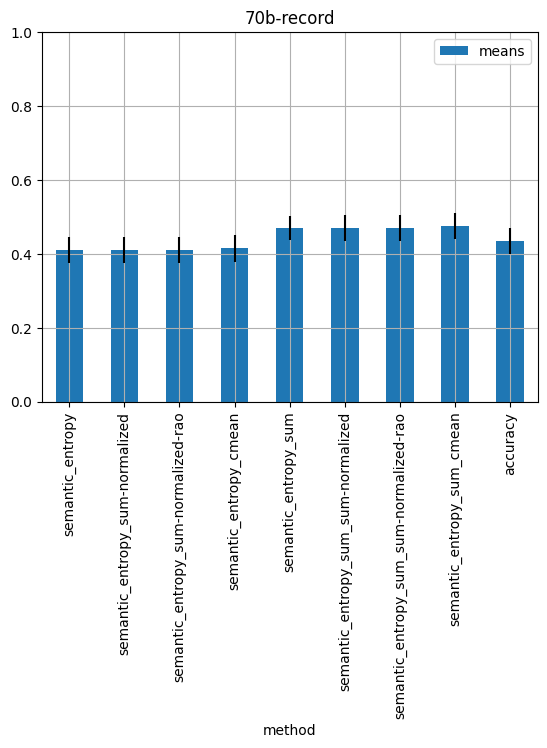

In [6]:
for wandb_id, run_name in runs.items():
    config = all_configs[wandb_id]
    results = all_results[wandb_id]

    df = get_perfs(results)
    plot_bar(df)
    plt.gca().set_title(run_name)
    plt.gca().grid()
    plt.gca().set_ylim(0, 1)


In [7]:
perfdf = {}
for wandb_id, run_name in runs.items():
    results = all_results[wandb_id]    
    perfdf[wandb_id] = get_perfs(results)

runids = list(perfdf.keys())
tmp = pd.DataFrame(perfdf[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(perfdf[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

perfdf = tmp.reset_index()

Text(0, 0.5, 'accuracy')

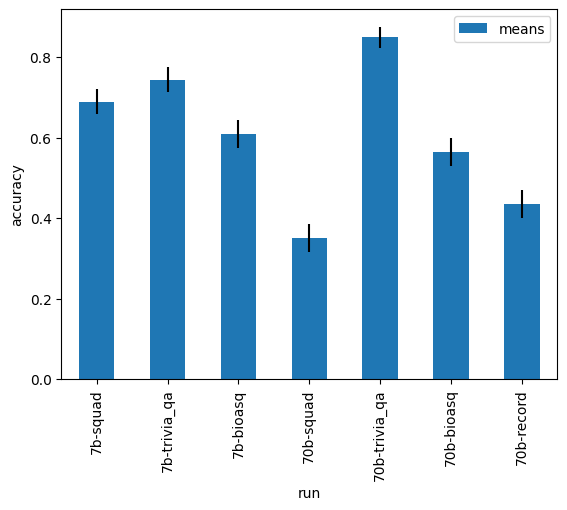

In [8]:
plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run'))
plt.gca().set_ylabel('accuracy')

In [9]:
tmp = perfdf.set_index('method').loc['accuracy']
tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
tmp.pivot(columns='model', index='dataset', values='means')

model,70b,7b
dataset,,
bioasq,0.565,0.610
record,0.435,NaN
squad,0.350,0.690
trivia_qa,0.850,0.745


* 7b largely performs very similar to 70b, usually a little worse (5-10%)
* Only big difference is for trivia-qa, where removing context leads to ~20 percent accuracy hit from ~85 to ~65 (this is not necessarily bad for us though)


In [10]:
metric_names = [
    'AUROC',
    'area_under_thresholded_accuracy',
    'mean_uncertainty',
    'accuracy_at_0.8_answer_fraction',
    'accuracy_at_0.9_answer_fraction',
    'accuracy_at_0.95_answer_fraction'
]

pdfs = {}
for wandb_id in runs:
    results = all_results[wandb_id]
    pdfs[wandb_id] = get_uncertainty_df(results)

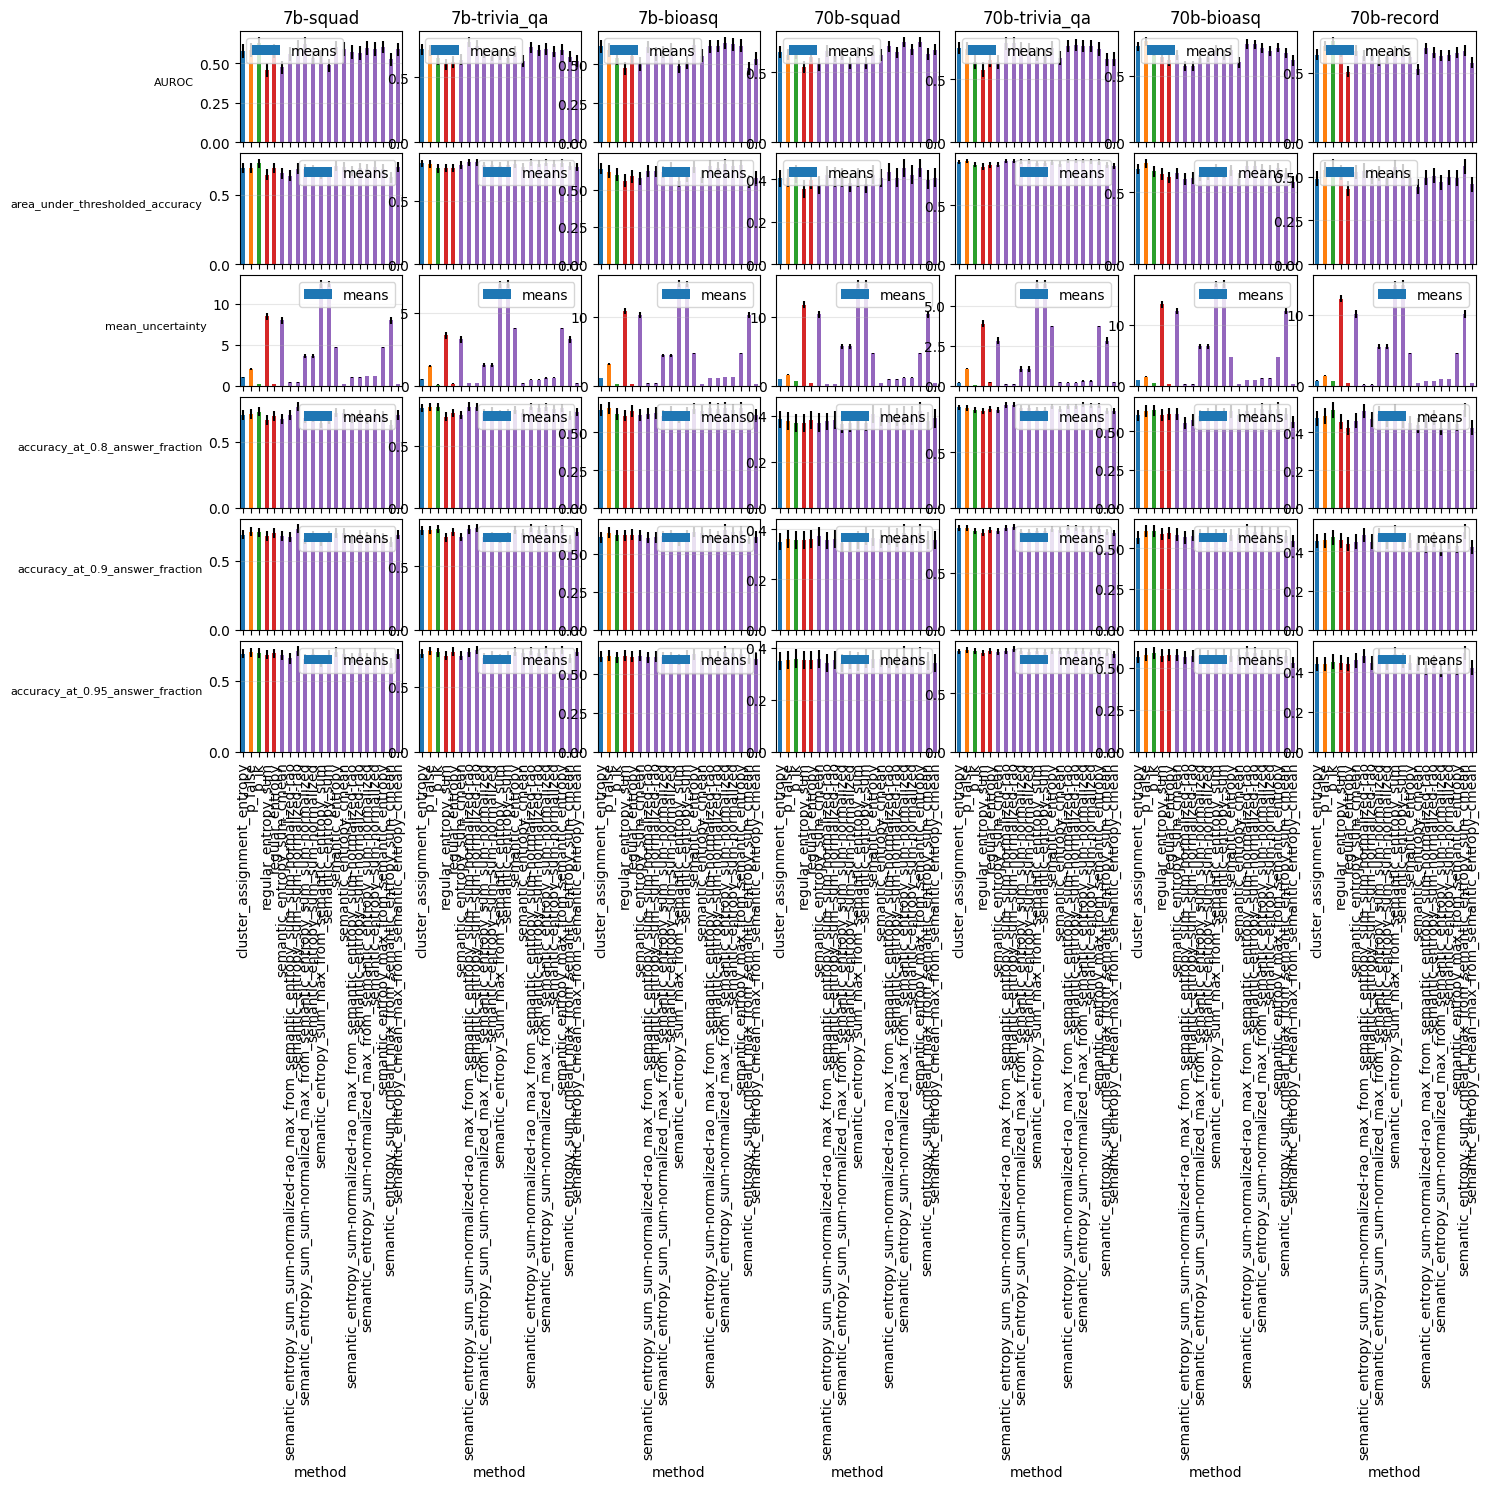

In [11]:
fig, axes_2d = plt.subplots(len(metric_names), len(runs), sharex=True, figsize=(15, 15), dpi=100)
# fig.suptitle(config['dataset']['value'] + ' '+ plt.gca().get_title())
for k, (name, axes) in enumerate(zip(list(metric_names), axes_2d)):

    for i, (ax, wandb_id) in enumerate(zip(axes, runs)):
        plot_bar_uncertainty(pdfs[wandb_id], name, ax=ax)

        if i == 0:
            ax.set_ylabel(name, fontsize=8, rotation=0, ha='right')

        if k == 0:
            ax.set_title(runs[wandb_id])


plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [12]:
runids = list(pdfs.keys())

tmp = pd.DataFrame(pdfs[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(pdfs[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

all_runs = tmp.reset_index()

/tmp/ipykernel_67983/1764243749.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_67983/1764243749.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


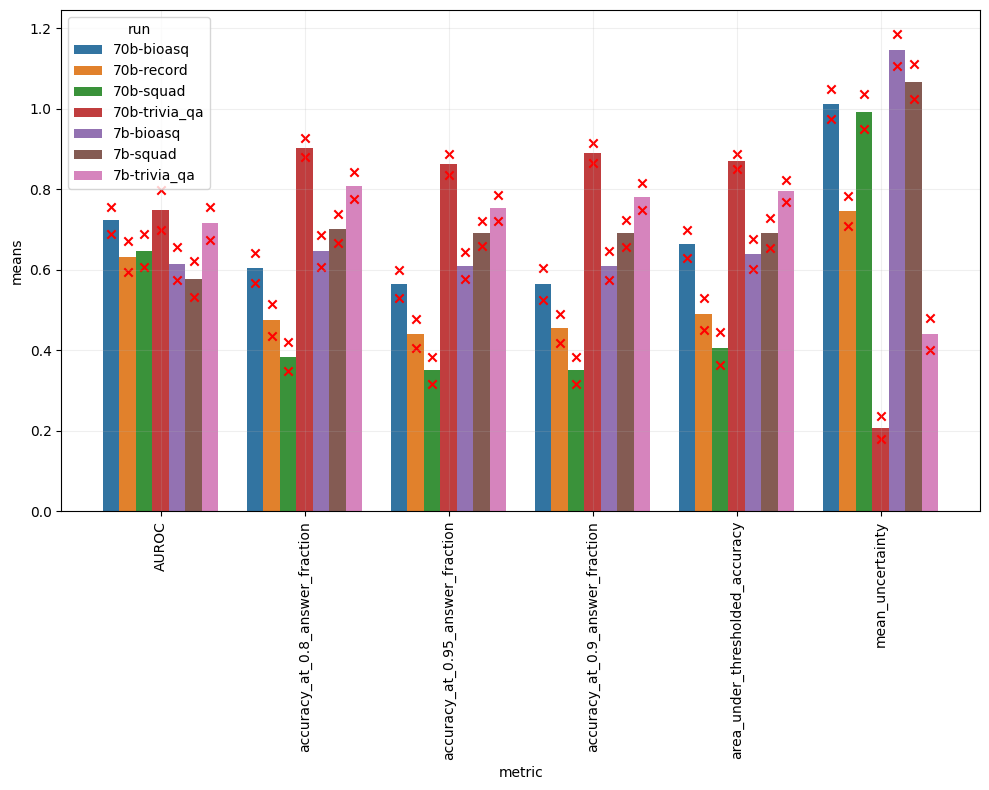

In [13]:
df2 = deepcopy(all_runs)
df2 = df2[all_runs.method == 'cluster_assignment_entropy']
df2 = df2.sort_values(['run', 'metric'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="metric",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_67983/1448009336.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[all_runs.metric != 'mean_uncertainty']
/tmp/ipykernel_67983/1448009336.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_67983/1448009336.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


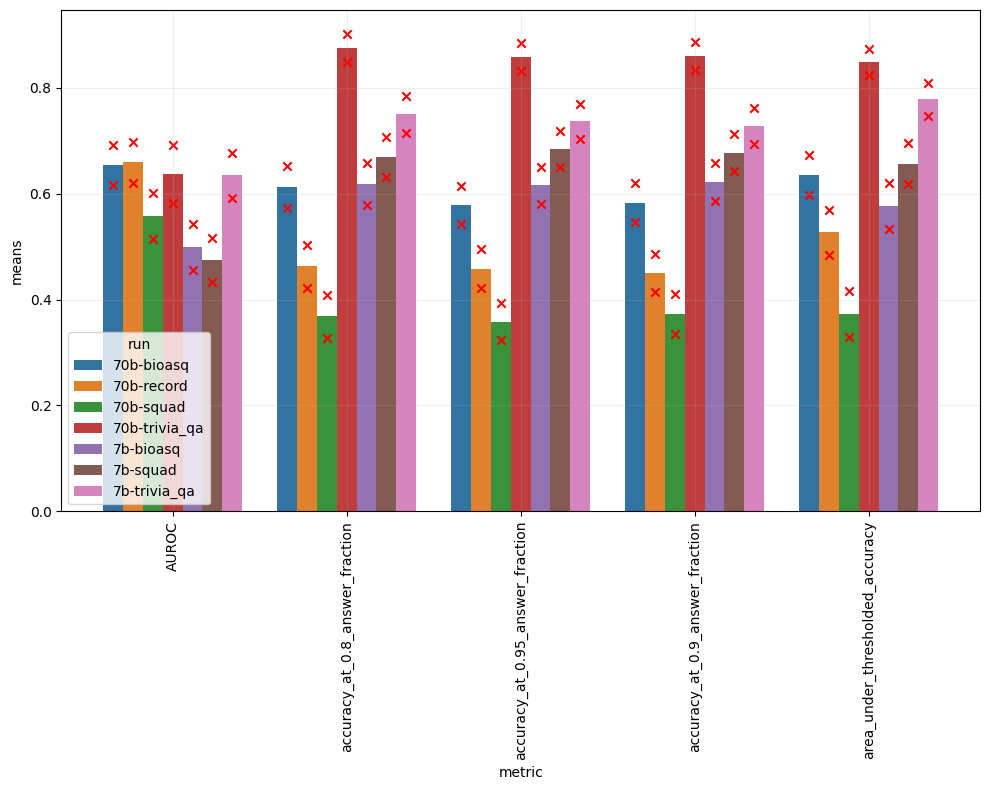

In [14]:
df2 = deepcopy(all_runs)
df2 = df2[all_runs.method == 'semantic_entropy_sum_cmean']
df2 = df2[all_runs.metric != 'mean_uncertainty']

df2 = df2.sort_values(['run', 'metric'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="metric",       # x variable name
    y="means",       # y variable name
    hue="run",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_67983/3628602304.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_67983/3628602304.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


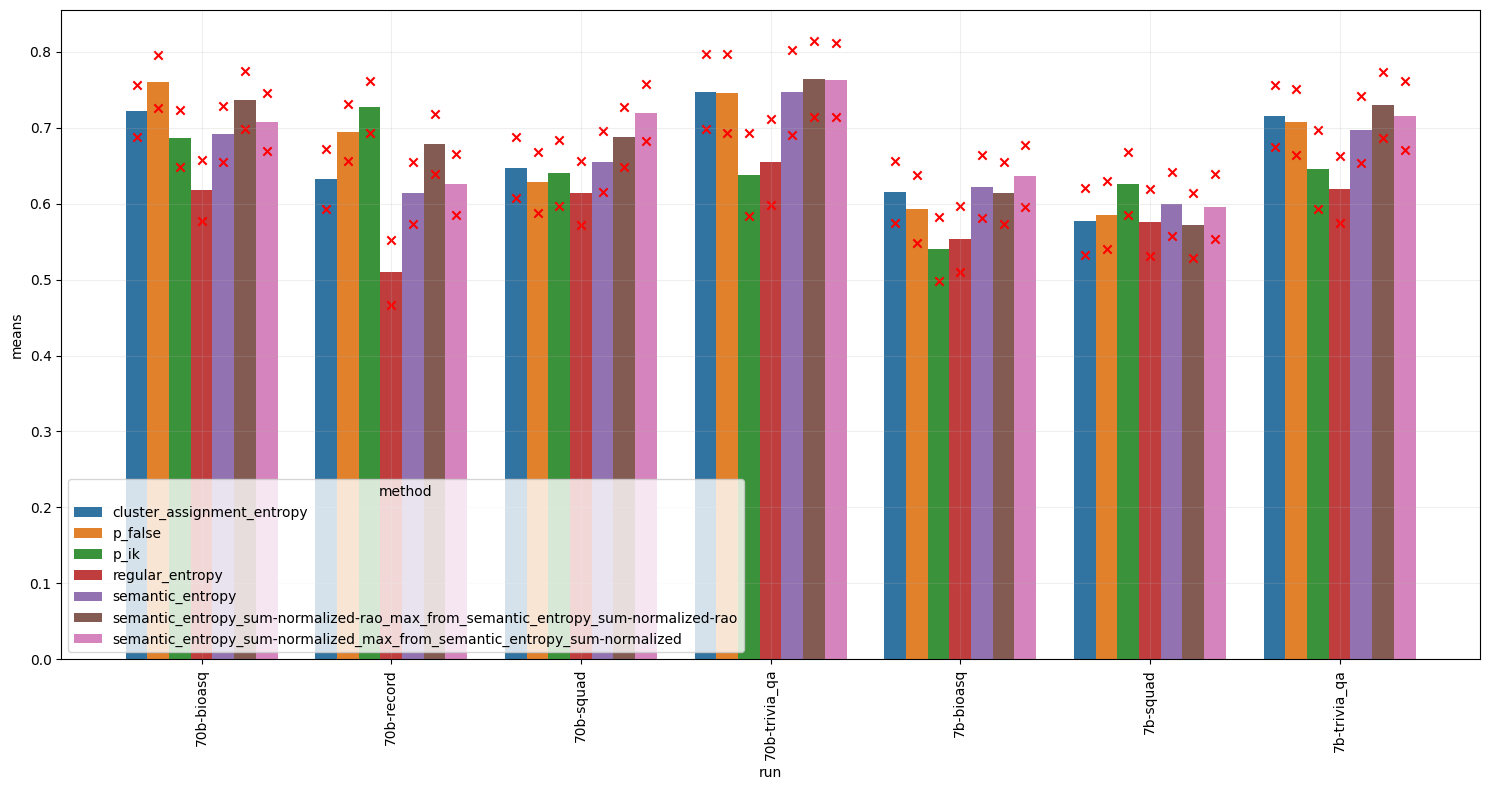

In [15]:
df2 = deepcopy(all_runs)
df2 = df2[df2.metric == 'AUROC']
main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized', 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']

df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2.sort_values(['method', 'run'])

fig, ax = plt.subplots(1, 1, figsize=(15, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

/tmp/ipykernel_67983/749225566.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_67983/749225566.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


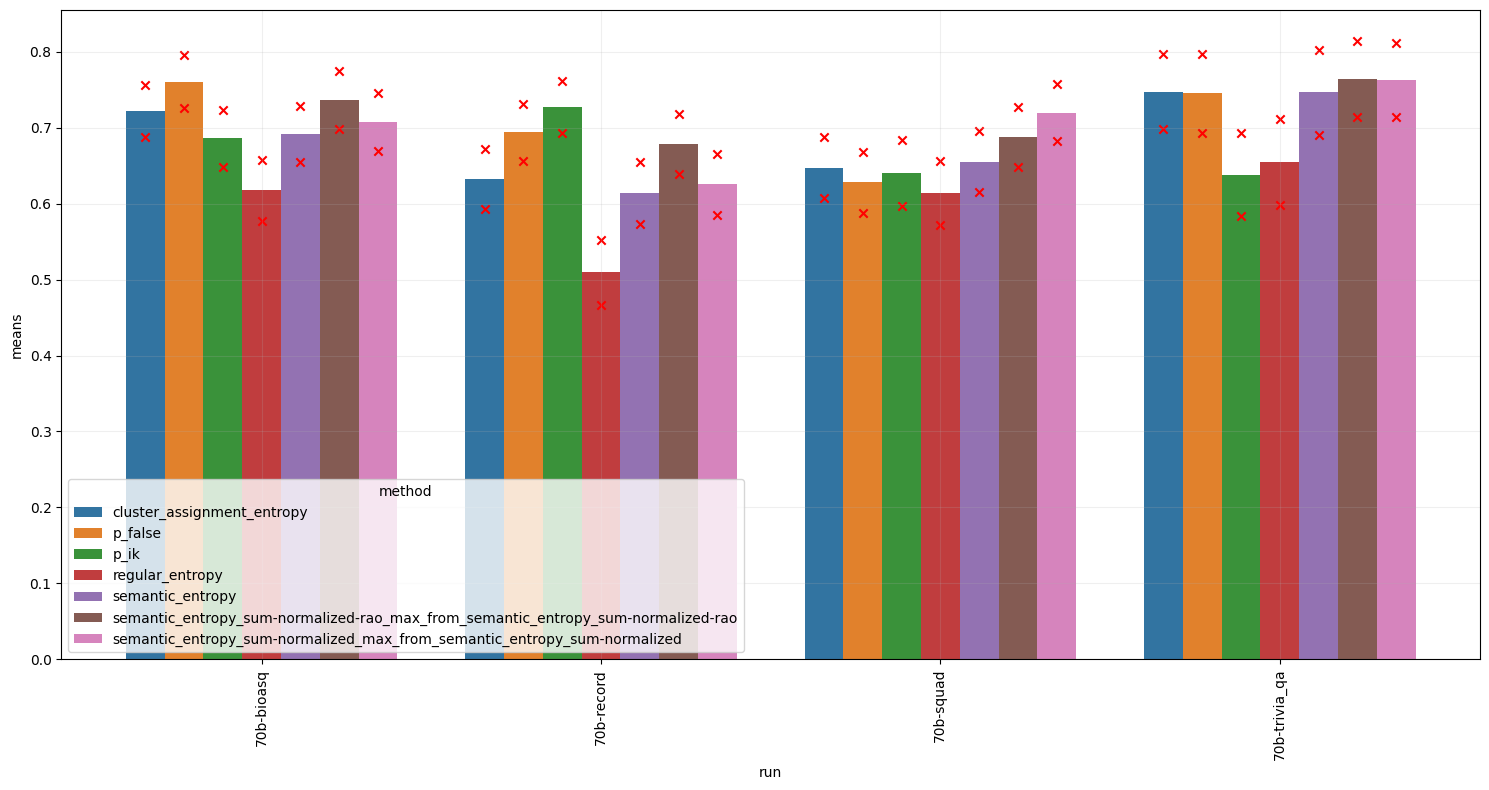

In [29]:
df2 = deepcopy(all_runs)
df2 = df2[df2.metric == 'AUROC']
main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized', 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']

df2 = df2[df2.method.map(lambda x: x in main_methods)]
df2 = df2[df2.run.map(lambda x: '70b' in x)]
# df2 = df2[df2.run.map(lambda x: 'record' not in x)]

df2 = df2.sort_values(['method', 'run'])

fig, ax = plt.subplots(1, 1, figsize=(15, 8), sharey=True, dpi=100)

g = sns.barplot(
    x="run",       # x variable name
    y="means",       # y variable name
    hue="method",  # group variable name
    data=df2,     # dataframe to plot
    ax=ax,
)

# https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
y_coords = [p.get_height() for p in ax.patches]

for kind in ['low', 'high']:
    tmp = df2[kind].values
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
ax.grid(zorder=-100, alpha=0.2)
# ax.set_ylim(0.3, 1)
plt.tight_layout()

In [30]:
tmp = all_runs.set_index('metric').loc['AUROC']
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]

In [31]:
# for each run (and for each model) I would like to see the best methods

In [32]:
# semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao --> this was the best method for short generations as well!

In [33]:
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.683373,0.641373,0.725372
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized,0.680629,0.638822,0.722436
semantic_entropy_max_from_semantic_entropy,0.677896,0.636003,0.719788
p_false,0.673584,0.631179,0.715990
semantic_entropy_sum-normalized-rao,0.669795,0.628984,0.710607
semantic_entropy_sum-normalized,0.665943,0.624221,0.707664
cluster_assignment_entropy,0.665456,0.624154,0.706758
semantic_entropy,0.661196,0.618178,0.704213
semantic_entropy_sum_sum-normalized-rao_max_from_semantic_entropy_sum_sum-normalized-rao,0.654055,0.611715,0.696394


In [35]:
tmp[tmp.run.map(lambda x: '70b' in x and 'record' not in x)].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized,0.730277,0.689011,0.771544
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.729703,0.687202,0.772203
semantic_entropy_max_from_semantic_entropy,0.723146,0.679955,0.766336
semantic_entropy_sum-normalized-rao,0.718033,0.677487,0.758579
p_false,0.711556,0.669339,0.753774
semantic_entropy_sum-normalized,0.707167,0.666336,0.747999
cluster_assignment_entropy,0.705908,0.664625,0.747192
semantic_entropy,0.698217,0.653932,0.742501
semantic_entropy_sum_max_from_semantic_entropy_sum,0.678537,0.634442,0.722632


In [34]:
tmp[tmp.run.map(lambda x: '70b' in x)].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.716949,0.675224,0.758674
p_false,0.707174,0.666164,0.748185
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized,0.704048,0.663010,0.745087
semantic_entropy_max_from_semantic_entropy,0.703945,0.661362,0.746527
semantic_entropy_sum-normalized-rao,0.699660,0.659345,0.739976
cluster_assignment_entropy,0.687604,0.646744,0.728464
semantic_entropy_sum-normalized,0.686985,0.646087,0.727883
semantic_entropy,0.677258,0.633911,0.720605
p_ik,0.673123,0.630563,0.715683


In [ ]:
tmp[tmp.run.map(lambda x: '7b' in x)].groupby('method').mean('means').sort_values('means', ascending=False)

In [ ]:
tmp.set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)

In [ ]:
tmp[tmp.run.map(lambda x: '7b' in x)].set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)